# Imports/Settings

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# 1. Стандартная библиотека
import os
import sys
import warnings
from pathlib import Path
import joblib

# --- ДИНАМИЧЕСКИЙ РАСЧЕТ АБСОЛЮТНЫХ ПУТЕЙ ---
notebook_dir = Path(os.getcwd()).resolve()
if notebook_dir.name == "notebooks":
    PROJECT_ROOT = notebook_dir.parent
else:
    PROJECT_ROOT = notebook_dir

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# 3. Локальные модули
from core.data import UniversalDataLoader
from core.models import get_model
from core.utils import load_hydra_config

# --- РАБОТА С ПРЕДУПРЕЖДЕНИЯМИ ---
warnings.filterwarnings('ignore', category=UserWarning, module='shap')
warnings.filterwarnings('ignore', category=FutureWarning)

# --- ИНИЦИАЛИЗАЦИЯ HYDRA ---
load_hydra_config.cache_clear()
cfg = load_hydra_config()

reports_dir = Path(cfg.paths.reports_dir)
reports_dir.mkdir(exist_ok=True)

print(f"Проект: {cfg.project_name} | Режим: Error Analysis")

# --- НАСТРОЙКИ ВИЗУАЛИЗАЦИИ ---
try:
    p_cfg = cfg.logging.plots
    plt.style.use(p_cfg.style)
    plt.rcParams.update({
        'figure.figsize': p_cfg.fig_size,
        'figure.dpi': p_cfg.dpi,
        'font.size': p_cfg.font_size,
        'axes.grid': p_cfg.grid,
        'axes.spines.top': p_cfg.spines_top,
        'axes.spines.right': p_cfg.spines_right
    })
    PLOT_ALPHA = p_cfg.alpha
except AttributeError:
    PLOT_ALPHA = 0.5
    print("Используются дефолтные стили Matplotlib.")

Проект: outsource_project_name | Режим: Error Analysis


# Data Loading

In [3]:
df = pd.read_parquet(f"{cfg.paths.processed_dir}/df_processedv0.0.pq")

In [4]:
loader = UniversalDataLoader(cfg)
# df = loader.load_data()
_, val_df, _ = loader.get_splits(df)

target = cfg.data.tabular.target_col
X_val, y_val = val_df.drop(columns=[target]), val_df[target]

# Пути к сохраненным объектам
models_dir = PROJECT_ROOT / cfg.paths.models_dir
model_version = cfg.model.model_version
preprocessor_version = cfg.data.tabular.preprocessing_version
model_name = cfg.model.name

In [5]:
print("Загрузка препроцессора и пайплайна модели...")
prep = joblib.load(models_dir / f"preprocessing_v{preprocessor_version}.pkl")

model_wrapper = get_model(cfg)
model_wrapper.load(str(models_dir / f"{model_name}_v{model_version}.cbm"))

# Трансформируем признаки (SHAP требует матрицу, которую видела сама модель на входе в fit)
X_val_clean = prep.transform(X_val)

Загрузка препроцессора и пайплайна модели...


In [6]:
# Превращаем в DataFrame с правильными именами колонок после препроцессинга
if hasattr(prep, 'get_feature_names_out'):
    feature_names = prep.get_feature_names_out()
    X_val_clean_df = pd.DataFrame(X_val_clean, columns=feature_names)
else:
    X_val_clean_df = pd.DataFrame(X_val_clean, columns=X_val.columns)

print(f"Данные готовы к расчету SHAP-значений. Формат: {X_val_clean_df.shape}")

Данные готовы к расчету SHAP-значений. Формат: (9256, 12)


# SHAP Explainer init

In [7]:
print("Инициализация TreeExplainer...")

# Достаем чистую нативную модель из нашей ООП-обертки
native_model = model_wrapper.model

explainer = shap.TreeExplainer(native_model)

print("Расчет SHAP-значений для валидационной выборки...")
# Чтобы не ждать слишком долго на гигантских датасетах,
# можно взять подмножество, например: X_val_clean_df.head(1000)
shap_values = explainer(X_val_clean_df)

print("Расчет успешно завершен!")

Инициализация TreeExplainer...
Расчет SHAP-значений для валидационной выборки...
Расчет успешно завершен!


# Global interpretation

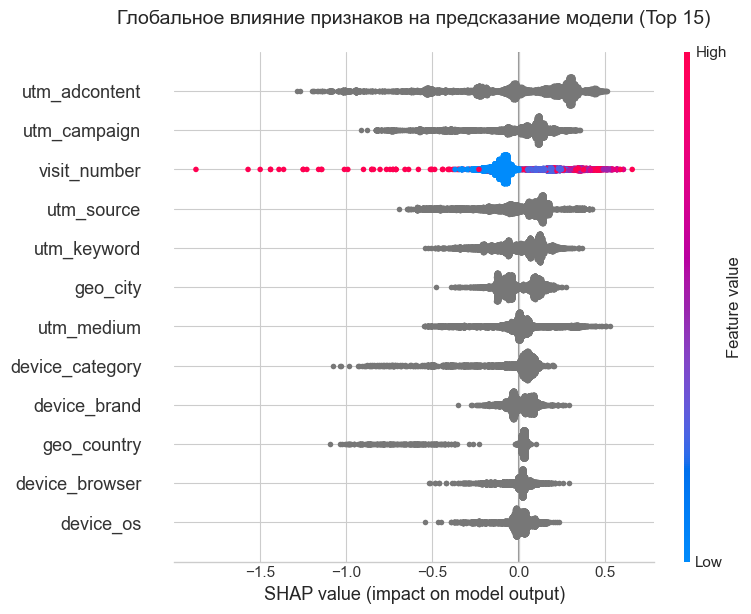

In [8]:
plt.figure()

# Beeswarm plot показывает распределение влияния каждого признака
# Каждая точка — это один юзер/сессия.
# Направление вправо — увеличивает предсказание, влево — уменьшает.
shap.plots.beeswarm(shap_values, max_display=15, show=False)

plt.title("Глобальное влияние признаков на предсказание модели (Top 15)", fontsize=14, pad=20)
plt.tight_layout()

# Сохраняем график в папку отчетов, путь к которой берем строго из твоего paths.yaml
reports_dir = Path(cfg.paths.reports_dir)
reports_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(reports_dir / "shap_global_summary.png", bbox_inches='tight')

plt.show()

In [10]:
global_importance = np.abs(shap_values.values).mean(0)
feature_importance_df = pd.DataFrame({
    'Feature': X_val_clean_df.columns,
    'Importance (mean |SHAP|)': global_importance
}).sort_values(by='Importance (mean |SHAP|)', ascending=False)

print("=== ТОП ПРИЗНАКОВ ПО ВЛИЯНИЮ НА МОДЕЛЬ ===")
display(feature_importance_df.head(15))

# Сохраняем текстовую таблицу в отчеты
feature_importance_df.to_csv(reports_dir / f"shap_feature_importance_v{model_version}.csv", index=False)

=== ТОП ПРИЗНАКОВ ПО ВЛИЯНИЮ НА МОДЕЛЬ ===


,Feature,Importance (mean |SHAP|)
4,utm_adcontent,0.266666
3,utm_campaign,0.148478
0,visit_number,0.144698
1,utm_source,0.141550
5,utm_keyword,0.113494
11,geo_city,0.092658
2,utm_medium,0.080657
6,device_category,0.078894
8,device_brand,0.052806
10,geo_country,0.048615


<Figure size 1000x600 with 0 Axes>

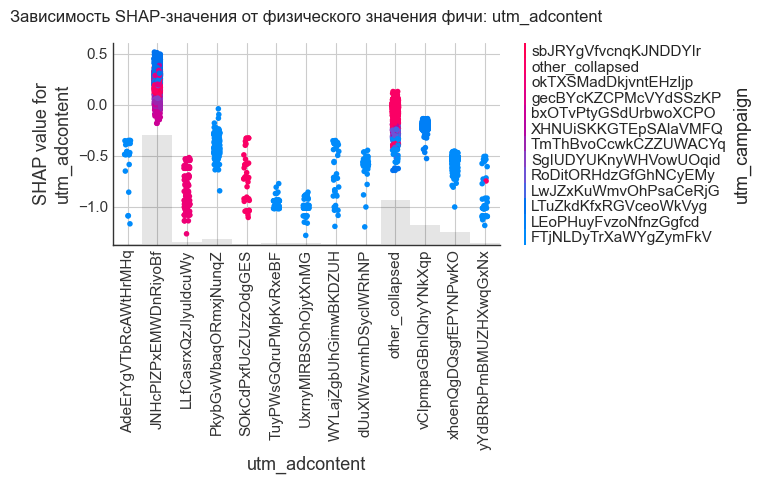

In [11]:
# Выбираем самый важный признак (первый в списке важности)
top_feature = feature_importance_df.iloc[0]['Feature']

plt.figure(figsize=(10, 6))
# SHAP dependence plot покажет зависимость и автоматически подберет фичу-партнера для раскраски
shap.plots.scatter(shap_values[:, top_feature], color=shap_values, show=False)

plt.title(f"Зависимость SHAP-значения от физического значения фичи: {top_feature}", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(reports_dir / f"shap_dependence_{top_feature}.png", bbox_inches='tight')
plt.show()

# Local Interpretation

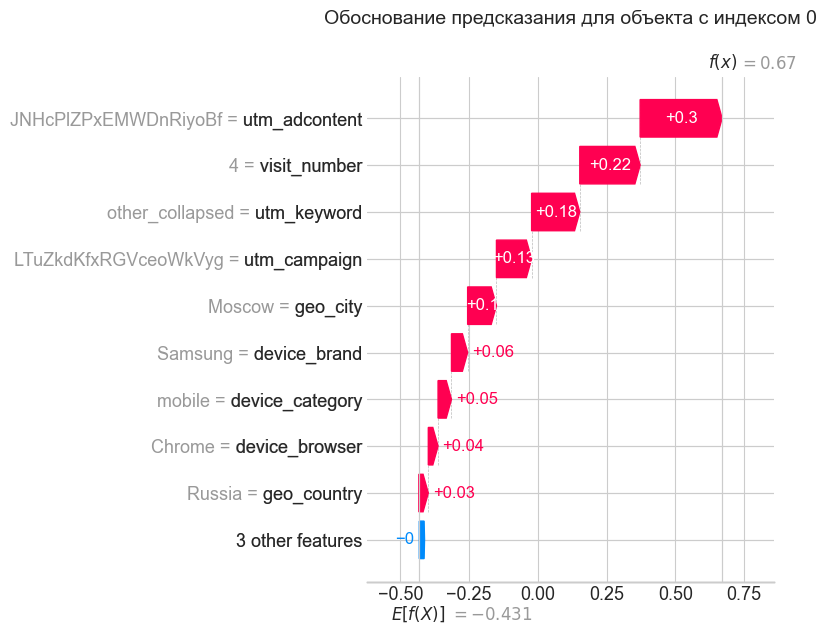

Фактическое значение таргета для этого объекта: 0


In [9]:
# Выбираем индекс конкретного наблюдения для анализа (например, нулевой юзер в выборке)
sample_index = 0

plt.figure()

# Waterfall plot наглядно показывает стартовую базовую вероятность (E[f(X)])
# и то, как каждый фактор шаг за шагом прибавил или отнял проценты до финального ответа.
shap.plots.waterfall(shap_values[sample_index], max_display=10, show=False)

plt.title(f"Обоснование предсказания для объекта с индексом {sample_index}", fontsize=14, pad=20)
plt.tight_layout()

# Сохраняем локальный отчет
plt.savefig(reports_dir / f"shap_local_user_{sample_index}.png", bbox_inches='tight')
plt.show()

print(f"Фактическое значение таргета для этого объекта: {y_val.iloc[sample_index]}")

=== АНАЛИЗ SHAP ДЛЯ ЛОЖНЫХ СРАБАТЫВАНИЙ (Найдено объектов: 3529) ===


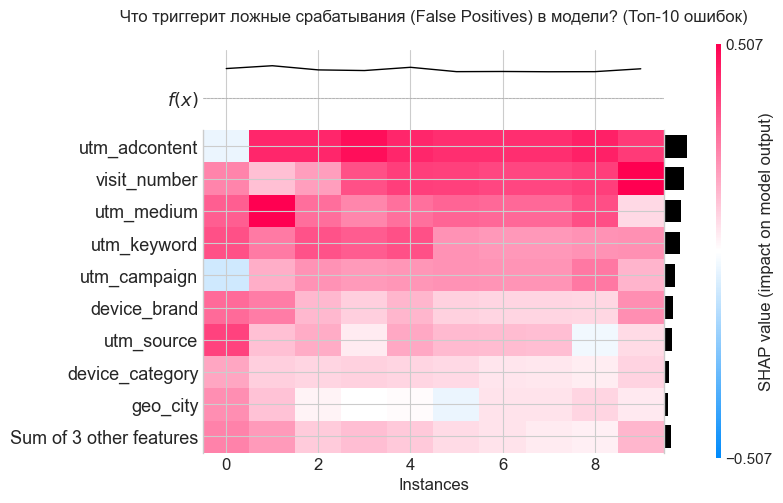

In [12]:
# 1. Считаем предсказания и размечаем типы прогнозов (как в прошлом ноутбуке)
preds = model_wrapper.predict(X_val_clean)
error_df = X_val.copy()
error_df['Actual'] = y_val.values
error_df['Predicted'] = preds

# Индексы ложных срабатываний (False Positives)
fp_indices = np.where((error_df['Actual'] == 0) & (error_df['Predicted'] == 1))[0]

if len(fp_indices) > 0:
    print(f"=== АНАЛИЗ SHAP ДЛЯ ЛОЖНЫХ СРАБАТЫВАНИЙ (Найдено объектов: {len(fp_indices)}) ===")
    
    # Берем топ-10 самых наглых ошибок FP
    if 'Probability' in error_df.columns or hasattr(model_wrapper, 'predict_proba'):
        probs = model_wrapper.predict_proba(X_val_clean)[:, 1]
        error_df['Probability'] = probs
        worst_fp_idx = error_df.iloc[fp_indices].sort_values(by='Probability', ascending=False).head(10).index
        # Переводим индексы датафрейма в позиционные индексы массива numpy
        pos_indices = [error_df.index.get_loc(idx) for idx in worst_fp_idx]
    else:
        pos_indices = fp_indices[:10]
        
    # Строим Heatmap для этих ошибок
    plt.figure(figsize=(12, 6))
    shap.plots.heatmap(shap_values[pos_indices], max_display=10, show=False)
    plt.title("Что триггерит ложные срабатывания (False Positives) в модели? (Топ-10 ошибок)", fontsize=12, pad=20)
    plt.tight_layout()
    plt.savefig(reports_dir / "shap_heatmap_false_positives.png", bbox_inches='tight')
    plt.show()
else:
    print("Ложных срабатываний для анализа не найдено.")